# Step 5: Checks and summary

Three things in this notebook:

1. A mass check: does the ice volume change by exactly the snowfall minus the ice that leaves at the calving front?
2. A summary of every run in steps 2 to 4.
3. How the results connect to my other projects: the graphical steady-state method of project 14, and why, in 1D, thinning the ice shelf (for example by ocean melting, the subject of project 16) cannot move the grounding line.

I load the libraries and model functions and set the parameters. The checks use the sub-grid scheme at 4 km and A = 3e-25 Pa^-3 s^-1, a cheap case from step 3 (about 8 seconds to steady state). Units: metres and years.

In [1]:
%matplotlib inline

import os
import time

import numpy as np
import matplotlib.pyplot as plt

from flowline import (ACCUMULATION, a_per_year, bed, make_grid, surface_elevation, thickness_above_flotation,
                      grounded_fraction_edges, solve_ssa, run_to_steady_state)

A_SI = 3e-25                  # rate factor (Pa^-3 s^-1)
A_YR = a_per_year(A_SI)
DX = 4e3                      # grid spacing for the checks (m)
SCHEME = "subgrid"
X_CALVING = 1600e3            # calving front (m)
H_INITIAL = 10.0              # starting thickness (m)
MELT_RATES = [2.0, 10.0]      # basal melt rates under the floating shelf (m/yr)
NAIVE_YEARS = 5000.0          # length of the run that melts the cell next to the grounding line (yr)
STEADY = dict(check_every=500.0, xg_rate_tol=0.1, dhdt_tol=1e-4, cfl=0.5, dt_max=10.0)   # as in step 3
FIG_DIR = "../figures"
DATA_DIR = "../data"

x_edges, x_centres = make_grid(X_CALVING, DX)
b_centres = bed(x_centres)

## 1. Mass check

Per metre of width, the ice volume is V = sum of H dx over all cells. Summing the update H_new = H + dt (a - (flux out - flux in)/dx) over all cells, every flux between two cells appears once with + and once with -, so only the two ends are left: the divide (flux 0) and the calving front. So over any time interval

change in V = (total snowfall a L t) - (total ice that crossed the calving front).

`run_to_steady_state` adds up both terms as it goes. Here I run from the 10 m layer to steady state and compare them at every check.

steady after 22000 years (7.7 s), grounding line 705.78 km
volume change 1.826951e+09 m^2 | snowfall - calving 1.826951e+09 m^2 | largest difference over all checks / largest change: 1.87e-14
thinnest ice anywhere at the end: 235.48 m
last 500 years: snowfall 480000.00 m^2/yr, calving 479841.55 m^2/yr (steady state: they should match; difference -0.0330%)


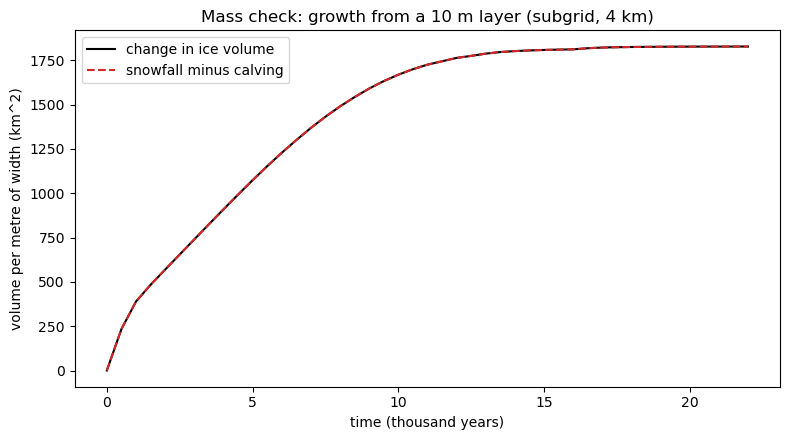

In [2]:
start = time.time()
base = run_to_steady_state(np.full(len(x_centres), H_INITIAL), x_centres, DX, A_YR, SCHEME, max_years=60000.0, **STEADY)
print(f"steady after {base['years']:.0f} years ({time.time() - start:.1f} s), grounding line {base['x_g'][-1] / 1e3:.2f} km")
change = base["volume"] - base["volume"][0]
budget = base["accumulated"] - base["calved"]
print(f"volume change {change[-1]:.6e} m^2 | snowfall - calving {budget[-1]:.6e} m^2 | "
      f"largest difference over all checks / largest change: {np.max(np.abs(change - budget)) / np.max(np.abs(change)):.2e}")
print(f"thinnest ice anywhere at the end: {base['h'].min():.2f} m")
rate_snow = (base["accumulated"][-1] - base["accumulated"][-2]) / (base["time"][-1] - base["time"][-2])
rate_calve = (base["calved"][-1] - base["calved"][-2]) / (base["time"][-1] - base["time"][-2])
print(f"last 500 years: snowfall {rate_snow:.2f} m^2/yr, calving {rate_calve:.2f} m^2/yr "
      f"(steady state: they should match; difference {100 * (rate_calve - rate_snow) / rate_snow:+.4f}%)")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(base["time"] / 1e3, change / 1e6, color="k", label="change in ice volume")
ax.plot(base["time"] / 1e3, budget / 1e6, color="tab:red", ls="--", label="snowfall minus calving")
ax.set_xlabel("time (thousand years)")
ax.set_ylabel("volume per metre of width (km^2)")
ax.set_title(f"Mass check: growth from a 10 m layer ({SCHEME}, {DX / 1e3:g} km)")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "05_mass_check.png"), dpi=150)
plt.show()

## 2. Summary of all runs

The solver test from step 2, the resolution test from step 3 and the hysteresis experiment from step 4, read from the files they saved in `data/`.

In [3]:
shelf = np.genfromtxt(os.path.join(DATA_DIR, "shelf_test_errors.csv"), delimiter=",", names=True)
print("Step 2, SSA solver on a thinning floating shelf (largest error / front speed):")
for row in shelf:
    print(f"  dx = {row['dx_km']:6.3f} km: {row['error_thinning']:.3e}")

res = np.genfromtxt(os.path.join(DATA_DIR, "resolution_test.csv"), delimiter=",", names=True, dtype=None, encoding=None)
print("\nStep 3, steady grounding line for A = 3e-25 (Schoof: 721.90 km):")
print(f"  {'scheme':8s} {'dx (km)':>8s} {'x_g (km)':>9s} {'error (km)':>11s} {'run time (s)':>13s}")
for row in res:
    print(f"  {row['scheme']:8s} {row['dx_km']:8.1f} {row['x_g_km']:9.2f} {row['error_km']:+11.2f} {row['run_time_s']:13.1f}")

hyst = np.genfromtxt(os.path.join(DATA_DIR, "hysteresis_steps.csv"), delimiter=",", names=True, dtype=None, encoding=None)
errors = np.array([row["error_km"] for row in hyst])
print(f"\nStep 4, hysteresis (sub-grid, 1 km): {len(hyst)} steps, {np.sum(hyst['years']):.0f} model years, "
      f"{np.sum(hyst['run_time_s']) / 60:.1f} minutes; error vs Schoof from {errors.min():+.1f} to {errors.max():+.1f} km, "
      f"median |error| {np.median(np.abs(errors)):.1f} km")

with open(os.path.join(DATA_DIR, "summary_table.csv"), "w") as f:
    f.write("step,scheme,dx_km,A_Pa-3_s-1,direction,x_g_km,schoof_km,error_km,run_time_s\n")
    for row in res:
        f.write(f"3,{row['scheme']},{row['dx_km']},3.0e-25,advance,{row['x_g_km']:.2f},721.90,{row['error_km']:.2f},{row['run_time_s']:.1f}\n")
    for row in hyst:
        f.write(f"4,subgrid,1.0,{row['A_Pa3_s1']:.1e},{row['direction']},{row['x_g_end_km']:.2f},{row['schoof_nearest_km']:.2f},"
                f"{row['error_km']:.2f},{row['run_time_s']:.1f}\n")
print("saved data/summary_table.csv")

Step 2, SSA solver on a thinning floating shelf (largest error / front speed):
  dx = 20.000 km: 1.552e-03
  dx = 10.000 km: 3.879e-04
  dx =  5.000 km: 9.697e-05
  dx =  2.500 km: 2.424e-05
  dx =  1.250 km: 6.052e-06
  dx =  0.625 km: 1.506e-06

Step 3, steady grounding line for A = 3e-25 (Schoof: 721.90 km):
  scheme    dx (km)  x_g (km)  error (km)  run time (s)
  plain         8.0    615.44     -106.45           3.1
  plain         4.0    639.79      -82.10           7.0
  plain         2.0    659.94      -61.96          16.8
  plain         1.0    676.99      -44.91          45.2
  plain         0.5    691.50      -30.40         136.9
  subgrid       8.0    691.84      -30.06           3.5
  subgrid       4.0    705.78      -16.11           8.1
  subgrid       2.0    710.98      -10.92          17.4
  subgrid       1.0    715.48       -6.42          43.7
  subgrid       0.5    717.73       -4.16         111.5

Step 4, hysteresis (sub-grid, 1 km): 13 steps, 221500 model years, 5.5

## 3a. The same method as project 14

In step 1 I found the steady states by plotting two curves against the grounding-line position, the snowfall upstream (a x_g) and the outflow (Schoof's q(x_g)), and looking for crossings. A crossing where the outflow curve rises faster than the snowfall line is stable; one where it rises more slowly is unstable. In project 14 I did exactly this for Stommel's box model, plotting the two sides of the steady-state equation against the density difference. In both cases the S-shaped curve of steady states against the control parameter (A here, the freshwater flux in Stommel's model) has two folds, and between them the system has two stable states and its history decides which one it is in.

## 3b. Why, in 1D, the ice shelf cannot hold the grounding line back

In step 2 I showed that on a freely floating shelf the stretching stress at every point equals the push of an ice cliff of the local thickness, 0.5 rho_i g (1 - rho_i/rho_w) H^2. At the grounding line H is fixed by the water depth, so the stress there does not depend on anything downstream: how long or thick the shelf is beyond the grounding line does not matter. In 1D a shelf cannot push back (buttress), because nothing holds it: there are no side walls and nothing it rests against.

First an instant test. I take the steady ice sheet, halve the thickness of the floating shelf (except the cell next to the grounding line, see below), and solve for the velocity again without changing anything else.

In [4]:
p = thickness_above_flotation(base["h"], x_centres)
first_floating = np.where((p[:-1] > 0) & (p[1:] <= 0))[0][0] + 1
h_thin = base["h"].copy()
h_thin[first_floating + 1:] = 0.5 * h_thin[first_floating + 1:]
fraction = grounded_fraction_edges(base["h"], x_centres, SCHEME)
u_before, n1, c1 = solve_ssa(base["h"], b_centres, DX, A_YR, fraction, u_guess=base["u"], tol=1e-12)
u_after, n2, c2 = solve_ssa(h_thin, b_centres, DX, A_YR, fraction, u_guess=base["u"], tol=1e-12)
grounded_edges = fraction > 0.999
print(f"shelf thickness halved from cell {first_floating + 1} on: mean shelf thickness "
      f"{base['h'][first_floating + 1:].mean():.0f} -> {h_thin[first_floating + 1:].mean():.0f} m")
print(f"largest change in velocity of grounded ice: {np.max(np.abs(u_after - u_before)[grounded_edges]):.2e} m/yr "
      f"(grounded ice moves at up to {u_before[grounded_edges].max():.0f} m/yr)")
print(f"speed at the calving front: {u_before[-1]:.0f} -> {u_after[-1]:.0f} m/yr")

shelf thickness halved from cell 177 on: mean shelf thickness 257 -> 128 m
largest change in velocity of grounded ice: 7.20e-10 m/yr (grounded ice moves at up to 276 m/yr)
speed at the calving front: 2038 -> 591 m/yr


Now ocean melting. I run the steady ice sheet forward with basal melting of 2 and 10 m/yr under the floating shelf until it is steady again. The melting never takes a cell below 1 m, and the ice it removes is added to the mass budget. I leave the first floating cell after the grounding line unmelted: on a 4 km grid its centre can be almost 4 km from the grounding line, where the real ice is still almost grounded.

In [5]:
melt_runs = {}
for melt in MELT_RATES:
    start = time.time()
    r = run_to_steady_state(base["h"], x_centres, DX, A_YR, SCHEME, max_years=60000.0, u_guess=base["u"], shelf_melt=melt, **STEADY)
    melt_runs[melt] = r
    floating = thickness_above_flotation(r["h"], x_centres) <= 0
    change = r["volume"] - r["volume"][0]
    budget = r["accumulated"] - r["calved"] - r["melted"]
    print(f"melt {melt:4.1f} m/yr: grounding line {base['x_g'][-1] / 1e3:.2f} -> {r['x_g'][-1] / 1e3:.2f} km "
          f"({(r['x_g'][-1] - base['x_g'][-1]) / 1e3:+.2f} km) | mean shelf thickness {base['h'][floating].mean():.0f} -> "
          f"{r['h'][floating].mean():.1f} m | steady {r['steady']} after {r['years']:.0f} yr | "
          f"mass check {np.max(np.abs(change - budget)) / np.max(np.abs(change)):.1e} | {time.time() - start:.1f} s")

melt  2.0 m/yr: grounding line 705.78 -> 705.67 km (-0.11 km) | mean shelf thickness 258 -> 29.6 m | steady True after 2000 yr | mass check 5.8e-15 | 0.9 s
melt 10.0 m/yr: grounding line 705.78 -> 705.79 km (+0.00 km) | mean shelf thickness 258 -> 8.5 m | steady True after 1000 yr | mass check 8.0e-16 | 0.1 s


The profiles before and after melting: the shelf almost disappears, the grounded ice sheet does not change.

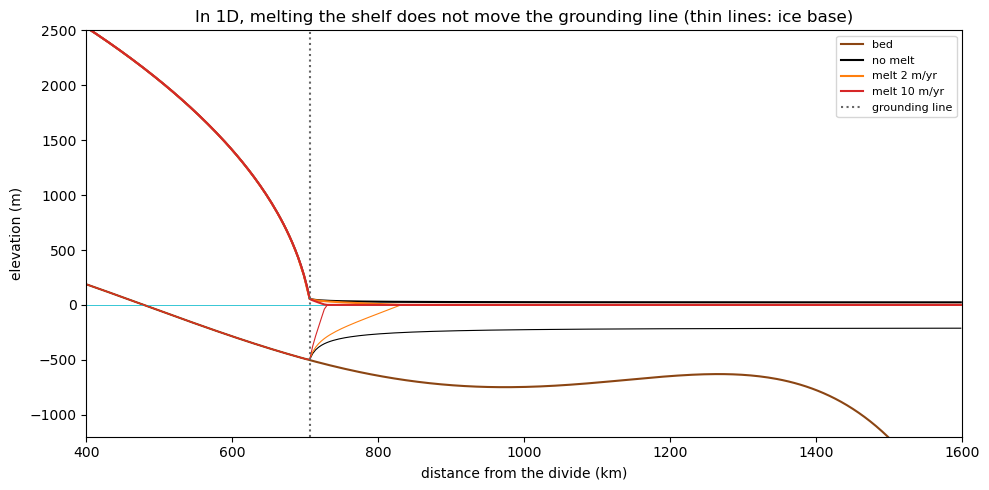

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_centres / 1e3, b_centres, color="saddlebrown", label="bed")
ax.axhline(0, color="tab:cyan", lw=0.6)
for label, h_plot, color in [("no melt", base["h"], "k")] + [(f"melt {m:g} m/yr", melt_runs[m]["h"], c) for m, c in zip(MELT_RATES, ["tab:orange", "tab:red"])]:
    s = surface_elevation(h_plot, b_centres)
    ax.plot(x_centres / 1e3, s, color=color, label=label)
    ax.plot(x_centres / 1e3, s - h_plot, color=color, lw=0.8)
ax.axvline(base["x_g"][-1] / 1e3, color="0.4", ls=":", label="grounding line")
ax.set_xlim(400, X_CALVING / 1e3)
ax.set_ylim(-1200, 2500)
ax.set_xlabel("distance from the divide (km)")
ax.set_ylabel("elevation (m)")
ax.set_title("In 1D, melting the shelf does not move the grounding line (thin lines: ice base)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "05_shelf_melt_profiles.png"), dpi=150)
plt.show()

A numerical lesson. My first version melted every floating cell, including the one right after the grounding line. With 10 m/yr the grounding line then retreated by tens of kilometres and had not stopped after 60 000 years. That retreat comes from the grid, not the physics: it melts ice that, on a finer grid, would be at or near the grounding line. Wang et al. (2024) and Seroussi and Morlighem (2018) found the same in 2D and 3D models, and recommend not melting the partly grounded cell. I show the first 5000 years of both versions.

after 5000 years of 10 m/yr melt: melting the first floating cell -> 668.98 km (-36.81 km); not melting it -> 705.79 km (+0.00 km) | 21.0 s


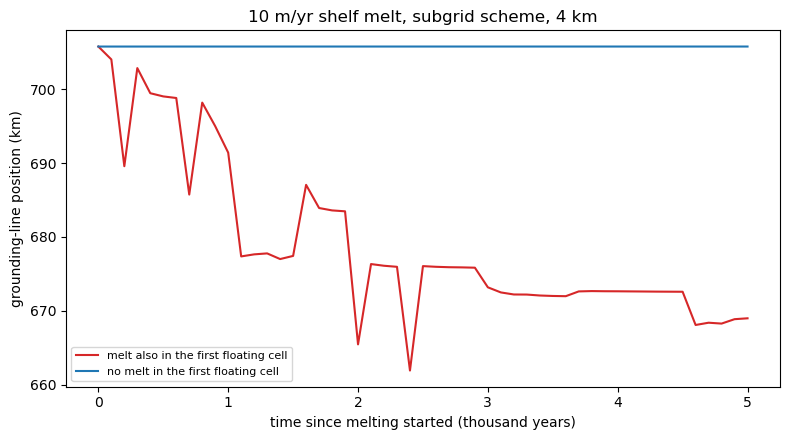

In [7]:
start = time.time()
naive = run_to_steady_state(base["h"], x_centres, DX, A_YR, SCHEME, max_years=NAIVE_YEARS, u_guess=base["u"], shelf_melt=10.0,
                            melt_first_floating_cell=True, check_every=100.0, xg_rate_tol=-1.0, dhdt_tol=-1.0, cfl=0.5, dt_max=10.0)
careful = run_to_steady_state(base["h"], x_centres, DX, A_YR, SCHEME, max_years=NAIVE_YEARS, u_guess=base["u"], shelf_melt=10.0,
                              check_every=100.0, xg_rate_tol=-1.0, dhdt_tol=-1.0, cfl=0.5, dt_max=10.0)
print(f"after {NAIVE_YEARS:.0f} years of 10 m/yr melt: melting the first floating cell -> {naive['x_g'][-1] / 1e3:.2f} km "
      f"({(naive['x_g'][-1] - base['x_g'][-1]) / 1e3:+.2f} km); not melting it -> {careful['x_g'][-1] / 1e3:.2f} km "
      f"({(careful['x_g'][-1] - base['x_g'][-1]) / 1e3:+.2f} km) | {time.time() - start:.1f} s")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(naive["time"] / 1e3, naive["x_g"] / 1e3, color="tab:red", label="melt also in the first floating cell")
ax.plot(careful["time"] / 1e3, careful["x_g"] / 1e3, color="tab:blue", label="no melt in the first floating cell")
ax.set_xlabel("time since melting started (thousand years)")
ax.set_ylabel("grounding-line position (km)")
ax.set_title(f"10 m/yr shelf melt, {SCHEME} scheme, {DX / 1e3:g} km")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "05_melt_next_to_grounding_line.png"), dpi=150)
plt.show()

## 3c. What this means for the real, 3D world

In my model the shelf can vanish and the grounding line stays put. Real ice shelves sit in embayments and rest on pinning points, so the side walls and bumps carry part of the shelf's push. The shelf then holds the grounded ice back (buttressing), and the stress at the grounding line is smaller than the free-floating value. Schoof (2007, Eq. 29) puts this into his flux formula with a factor theta < 1 on the stress, which multiplies the flux by theta^(n/(m+1)) = theta^(9/4). If ocean melting thins a buttressing shelf, theta rises toward 1, the flux across the grounding line increases, and the grounding line can retreat, possibly onto a reverse slope where the instability of step 4 takes over. That is why melting under ice shelves, which I modelled in project 16, matters for the ice sheet, even though in 1D it has no effect at all.